<a href="https://colab.research.google.com/github/rahitmaity231-lang/AI_LAB/blob/main/LAB1_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        BFS AND DFS GRAPH TRAVERSAL

Adjacency List:
A -> ['B', 'C']
B -> ['D', 'E']
C -> ['F']
D -> []
E -> []
F -> []

BFS Traversal:
A -> B -> C -> D -> E -> F

DFS Traversal:
A -> B -> D -> E -> C -> F



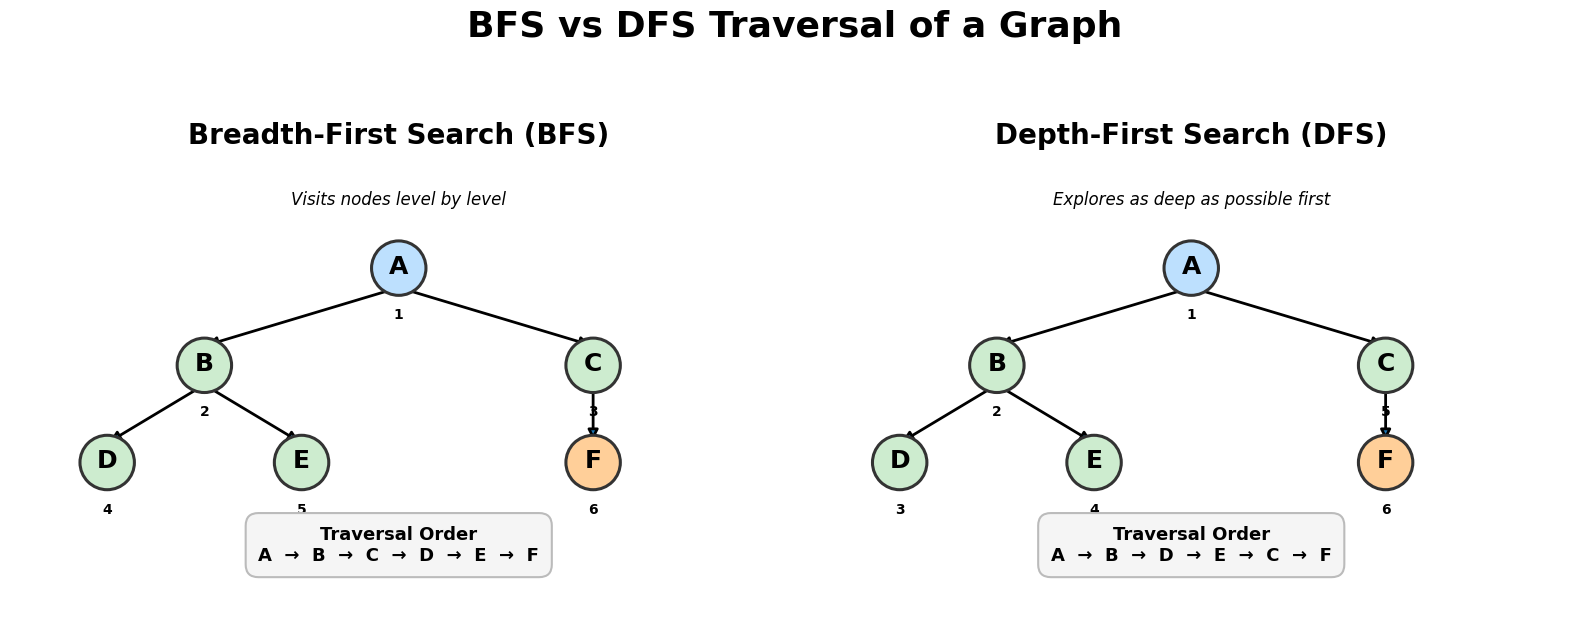

In [ ]:
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


# ============================================================
# 1. GRAPH REPRESENTATION USING AN ADJACENCY LIST
# ============================================================

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}


# ============================================================
# 2. BREADTH-FIRST SEARCH (BFS)
# ============================================================

def bfs(graph, start):
    visited = set()
    queue = deque([start])
    traversal = []

    visited.add(start)

    while queue:
        node = queue.popleft()
        traversal.append(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)

    return traversal


# ============================================================
# 3. DEPTH-FIRST SEARCH (DFS)
# ============================================================

def dfs(graph, start):
    visited = set()
    traversal = []

    def dfs_recursive(node):
        visited.add(node)
        traversal.append(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                dfs_recursive(neighbour)

    dfs_recursive(start)

    return traversal


# ============================================================
# 4. PERFORM BFS AND DFS
# ============================================================

bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')


# ============================================================
# 5. PRINT RESULTS
# ============================================================

print("=" * 55)
print("        BFS AND DFS GRAPH TRAVERSAL")
print("=" * 55)

print("\nAdjacency List:")
for node, neighbours in graph.items():
    print(f"{node} -> {neighbours}")

print("\nBFS Traversal:")
print(" -> ".join(bfs_order))

print("\nDFS Traversal:")
print(" -> ".join(dfs_order))

print("\n" + "=" * 55)


# ============================================================
# 6. FUNCTION TO DRAW A TREE
# ============================================================

def draw_tree(ax, traversal, title, subtitle):
    """
    Draws the graph as a tree and displays the traversal
    order inside each node.
    """

    # Node positions
    positions = {
        'A': (0, 3),
        'B': (-2, 2),
        'C': (2, 2),
        'D': (-3, 1),
        'E': (-1, 1),
        'F': (2, 1)
    }

    # --------------------------------------------------------
    # Draw edges
    # --------------------------------------------------------

    edges = [
        ('A', 'B'),
        ('A', 'C'),
        ('B', 'D'),
        ('B', 'E'),
        ('C', 'F')
    ]

    for parent, child in edges:
        x1, y1 = positions[parent]
        x2, y2 = positions[child]

        ax.annotate(
            '',
            xy=(x2, y2 + 0.20),
            xytext=(x1, y1 - 0.20),
            arrowprops=dict(
                arrowstyle='-|>',
                lw=2,
                mutation_scale=15
            )
        )

    # --------------------------------------------------------
    # Create visit-number dictionary
    # --------------------------------------------------------

    visit_number = {
        node: i + 1
        for i, node in enumerate(traversal)
    }

    # --------------------------------------------------------
    # Draw nodes
    # --------------------------------------------------------

    for node, (x, y) in positions.items():

        order = visit_number[node]

        # Different appearance for first, middle and last nodes
        if order == 1:
            face_color = "#BDE0FE"
        elif order == len(traversal):
            face_color = "#FFCF99"
        else:
            face_color = "#CDECCF"

        # Circular node
        circle = plt.Circle(
            (x, y),
            0.28,
            facecolor=face_color,
            edgecolor="#333333",
            linewidth=2.2,
            zorder=3
        )

        ax.add_patch(circle)

        # Node name
        ax.text(
            x,
            y + 0.02,
            node,
            ha='center',
            va='center',
            fontsize=18,
            fontweight='bold',
            zorder=4
        )

        # Visit number
        ax.text(
            x,
            y - 0.48,
             order,
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold'
        )

    # --------------------------------------------------------
    # Title and subtitle
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=20,
        fontweight='bold',
        pad=20
    )

    ax.text(
        0,
        3.65,
        subtitle,
        ha='center',
        fontsize=12,
        style='italic'
    )

    # --------------------------------------------------------
    # Traversal sequence box
    # --------------------------------------------------------

    sequence = "  →  ".join(traversal)

    ax.text(
        0,
        0.15,
        f"Traversal Order\n{sequence}",
        ha='center',
        va='center',
        fontsize=13,
        fontweight='bold',
        bbox=dict(
            boxstyle="round,pad=0.7",
            facecolor="#F5F5F5",
            edgecolor="#BBBBBB",
            linewidth=1.5
        )
    )

    # Formatting
    ax.set_xlim(-4, 4)
    ax.set_ylim(-0.6, 4)
    ax.set_aspect('equal')
    ax.axis('off')


# ============================================================
# 7. CREATE TWO SEPARATE TREE DIAGRAMS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)

fig.suptitle(
    "BFS vs DFS Traversal of a Graph",
    fontsize=26,
    fontweight='bold',
    y=0.98
)


# BFS diagram
draw_tree(
    axes[0],
    bfs_order,
    "Breadth-First Search (BFS)",
    "Visits nodes level by level"
)


# DFS diagram
draw_tree(
    axes[1],
    dfs_order,
    "Depth-First Search (DFS)",
    "Explores as deep as possible first"
)


# ============================================================
# 8. FINAL DISPLAY
# ============================================================

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()